<a href="https://colab.research.google.com/github/ctr/medical-physics-demos-2026-03/blob/main/MedPhys_sliceSelBloch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Slice selection using exponential time stepping

In [1]:
# Set up the python package "bloch" that we need. This will take a moment.
import importlib.util

if importlib.util.find_spec("bloch") is None:
    get_ipython().run_line_magic(
        "pip",
        "install -q --progress-bar off git+https://github.com/ctr/bloch-simulator-python"
    )
else:
    print("bloch is already installed.")

# Note that the original version was
# https://github.com/namalkanti/bloch-simulator-python
# but its setup script is incompatible with recent python versions

bloch is already installed.


In [2]:
# Import the bloch simulator and define some helper functions.
import numpy as np
import matplotlib.pyplot as plt
from bloch import bloch

# -------------------------------------------------
# Simulation parameters
# -------------------------------------------------
gamma = 2 * np.pi * 42.577e6   # rad/T/s
dt = 2e-6                      # 2 us dwell time
flip_angle_deg = 90            # 90 degree pulse
slice_thickness = 5e-3         # 5 mm
Gz = 10e-3                     # 10 mT/m slice gradient
T1 = 1.0                       # seconds
T2 = 0.1                       # seconds

# Spatial positions across slice
z = np.linspace(-10e-3, 10e-3, 1000)
df = gamma * Gz * z / (2*np.pi)   # convert these to frequency offsets (Hz) during the gradient

# -------------------------------------------------
# Function to generate non-windowed sinc pulse
# -------------------------------------------------
def sinc(num_lobes, duration, dt, start=None):
    # Note - pulses are truncated. This complicates keeping the same duration for sinc and windowed sinc. Fudge it here for now.
    t = np.arange(-duration/2, duration/2, dt)
    bw = ((num_lobes-1)*2) / duration
    rf = np.sinc(bw * t)
    
    if start is not None:
        # Shift the pulse in time by "start" seconds
        t += start - t[0]
    
    return t, rf

# -------------------------------------------------
# Function to generate a rect pulse
# -------------------------------------------------
def rect(duration, dt, start=None):
    t = np.arange(-duration/2, duration/2, dt)
    rf = np.ones_like(t)
    
    if start is not None:
        # Shift the pulse in time by "start" seconds
        t += start - t[0]
    
    # Set ends to zero for a prettier plot
    rf[0] = 0
    rf[-1] = 0

    return t, rf

# -------------------------------------------------
# Function to generate Hamming-windowed sinc pulse
# -------------------------------------------------
def hamming_sinc(num_lobes, duration, dt, start=None):
    t = np.arange(-duration/2, duration/2, dt)
    bw = num_lobes / duration
    sinc = np.sinc(bw * t)
    window = np.hamming(len(t))
    rf = sinc * window

    if start is not None:
        # Shift the pulse in time by "start" seconds
        t += start - t[0]
    
    return t, rf

# -------------------------------------------------
# Scale RF pulse to desired flip angle
# Note that bloch(...) expects the RF in units of Gauss i.e. 1e-4 T.
# -------------------------------------------------
def scale_rf(rf, dt, flip_angle_deg):
    b1_area = np.sum(rf) * dt
    scale = (flip_angle_deg/360) / ((1e-4 * gamma / (2*np.pi)) * b1_area)
    return rf * scale

# Utility function to compute dt from a time vector
def getTimeSpacing(arr):
    """Return spacing between first and second elements of a 1D NumPy array."""
    # TODO - check spacings are constant.
    if len(arr) < 2:
        raise ValueError("Array must have at least 2 elements")
    return arr[1] - arr[0]


Text(0.5, 1.0, 'Final Mz vs RF scale for 1 ms rect pulse')

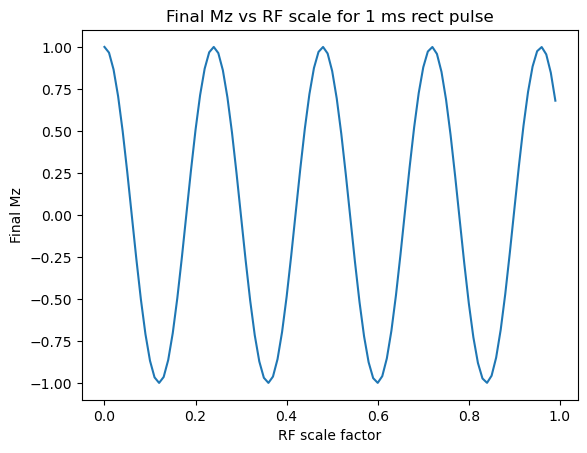

In [3]:
# Check the RF scaling

# 1G is 1e-4 T, which nutates at 1e-4 * gamma / (2*np.pi) Hz = 4258 Hz.
# So a 1 ms pulse at 1 G should give 4.25 full rotations.

tRect, rfRect = rect(1e-3, 1e-5) # 1 ms rectangular pulse with 1e-5 s dwell time (to get enough points for the bloch sim)

scaleVals = np.arange(0, 1, 0.01) # Scale from 0 to 1 in steps of 0.01
finalMzs = np.zeros_like(scaleVals)

for scaleDx in range(len(scaleVals)):
    rfRectScaled = rfRect * scaleVals[scaleDx]
    mxRect, myRect, mzRect = bloch(rfRectScaled, 0, getTimeSpacing(tRect), 1e3, 1e3, 0, 0, mode=0) # Neglect relaxation
    finalMzs[scaleDx] = mzRect[-1]

plt.figure()
plt.plot(scaleVals, finalMzs)
plt.xlabel("RF scale factor")
plt.ylabel("Final Mz")
plt.title("Final Mz vs RF scale for 1 ms rect pulse")


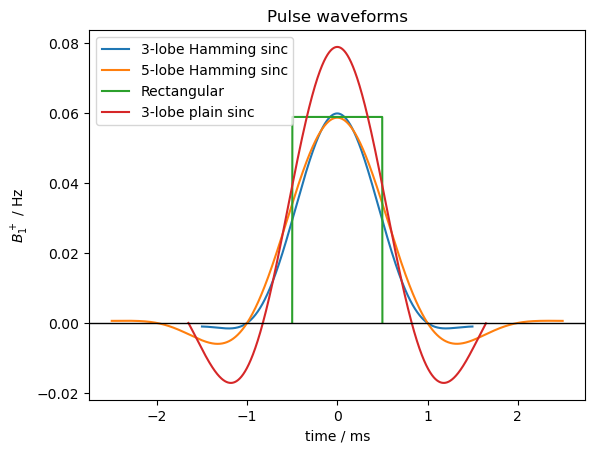

In [4]:
# --------------------------------------------------------------------------
# Create non-windowed 3-lobe, plus Hamming windowed 3-lobe and 5-lobe pulses
# --------------------------------------------------------------------------
duration_3 = 3e-3
duration_5 = 5e-3

t3, rf3 = hamming_sinc(3, duration_3, dt)
t5, rf5 = hamming_sinc(5, duration_5, dt)
tRect, rfRect = rect(1e-3, dt) # 1 ms rectangular pulse
t3NW, rf3NW = sinc(3, duration_3*1.1, dt*1.1)  # fudge the duration here to get the same main lobe width as the windowed version

rf3 = scale_rf(rf3, dt, flip_angle_deg)
rf5 = scale_rf(rf5, dt, flip_angle_deg)
rfRect = scale_rf(rfRect, dt, flip_angle_deg)
rf3NW = scale_rf(rf3NW, dt*1.1, flip_angle_deg)

# -------------------------------------------------
# Plot pulses
# -------------------------------------------------
plt.figure()
plt.plot(t3*1e3, rf3, label="3-lobe Hamming sinc")
plt.plot(t5*1e3, rf5, label="5-lobe Hamming sinc")
plt.plot(tRect*1e3, rfRect, label="Rectangular")
plt.plot(t3NW*1e3, rf3NW, label="3-lobe plain sinc")
plt.axhline(y=0, color='black', linewidth=1)  # horizontal line at y=0
plt.xlabel("time / ms")
plt.ylabel(r"$B_1^+$ / Hz")
plt.title("Pulse waveforms")
plt.legend()
plt.show()

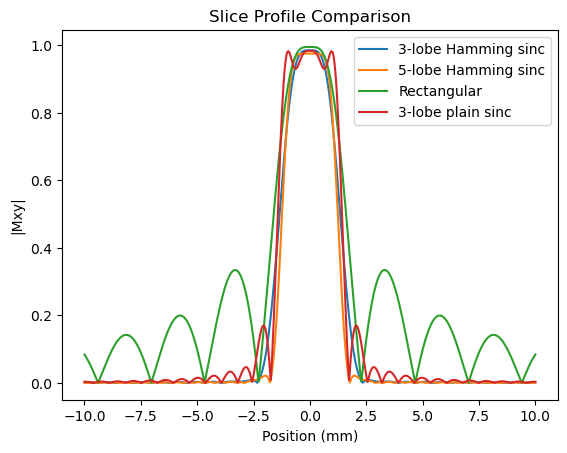

In [5]:
# -------------------------------------------------
# Bloch simulation
# -------------------------------------------------
mx3, my3, mz3 = bloch(rf3, np.ones_like(t3) * Gz, getTimeSpacing(t3), T1, T2, df, 0, mode=0)
mx5, my5, mz5 = bloch(rf5, np.ones_like(t5), getTimeSpacing(t5), T1, T2, df, 0, mode=0)
mxRect, myRect, mzRect = bloch(rfRect, np.ones_like(tRect) * Gz, getTimeSpacing(tRect), T1, T2, df, 0, mode=0)
mx3NW, my3NW, mz3NW = bloch(rf3NW, np.ones_like(t3NW) * Gz, getTimeSpacing(t3NW), T1, T2, df, 0, mode=0)

mxy3 = np.abs(mx3 + 1j*my3)
mxy5 = np.abs(mx5 + 1j*my5)
mxyRect = np.abs(mxRect + 1j*myRect)
mxy3NW = np.abs(mx3NW + 1j*my3NW)

# -------------------------------------------------
# Plot slice profiles
# -------------------------------------------------
plt.figure()
plt.plot(z*1e3, mxy3, label="3-lobe Hamming sinc")
plt.plot(z*1e3, mxy5, label="5-lobe Hamming sinc")
plt.plot(z*1e3, mxyRect, label="Rectangular")
plt.plot(z*1e3, mxy3NW, label="3-lobe plain sinc")
plt.xlabel("Position (mm)")
plt.ylabel("|Mxy|")
plt.title("Slice Profile Comparison")
plt.legend()
plt.show()